In [6]:
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects

from sklearn import datasets
from sklearn.decomposition import PCA
import numpy as np

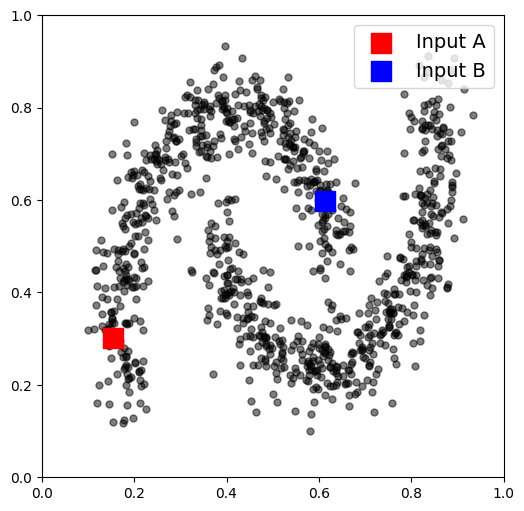

In [7]:
n_samples = 1000
seed = 42
noisy_moons = datasets.make_moons(n_samples=n_samples, 
                                  noise=0.12, 
                                  random_state=seed)

x_2d, y = noisy_moons
points = PCA(n_components=2).fit_transform(x_2d)
# points = x_2d

fig, ax = plt.subplots(figsize=(8, 6))

points[:, 0] = (points[:, 0] - points[:, 0].min()) / (points[:, 0].max() - points[:, 0].min()) / 1.2 + 0.1
points[:, 1] = (points[:, 1] - points[:, 1].min()) / (points[:, 1].max() - points[:, 1].min()) / 1.2 + 0.1

ax.set_aspect('equal')
ax.scatter(points[:, 0], points[:, 1], s=25, alpha=0.5, c='black', marker='o')

def find_closest(point, points):
    distances = ((points - point) ** 2).sum(axis=1)
    return points[distances.argmin()]

input1 = tuple(find_closest((0.15, 0.3), points))
input2 = tuple(find_closest((0.61, 0.6), points))
# input2 = tuple(find_closest((0.9, 0.9), points))

ax.scatter(input1[0], input1[1], c='red', marker='s', s=200, label="Input A")
ax.scatter(input2[0], input2[1], c='blue', marker='s', s=200, label="Input B")
# ax.scatter(input3[0], input3[1], c='green', marker='s', s=200, label="Input C")
ax.legend(loc='upper right', fontsize=14)

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
# ax.set_xticks([])
# ax.set_yticks([])

# Show the plot
plt.show()

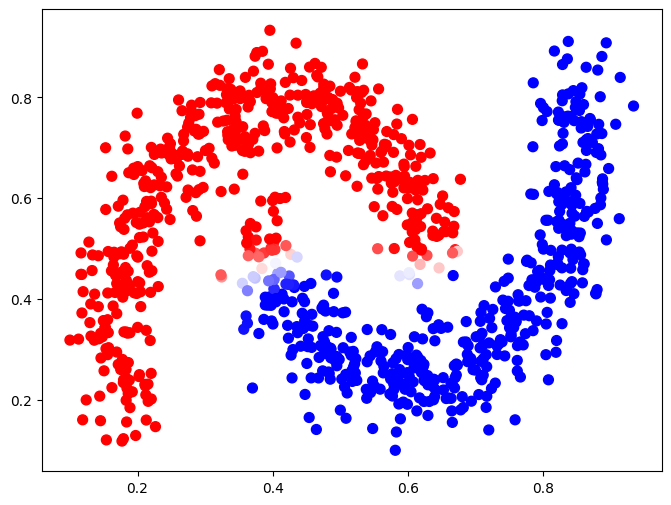

In [8]:
from ncut_pytorch import Ncut
from ncut_pytorch.utils.math import rbf_affinity
import torch

n_eig = 128
_points = torch.tensor(points).float()
np.random.seed(42)
torch.manual_seed(42)
ncut = Ncut(n_eig=n_eig, gamma=0.001, affinity_fn=rbf_affinity, extrapolation_factor=0.1).fit(_points)
eigvec = ncut.transform(_points)

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(points[:, 0], points[:, 1], c=eigvec[:, 1], 
           cmap='bwr', vmin=-0.2, vmax=0.2, s=50)
plt.show()

In [9]:
grid_size = 300
grid_xy = torch.stack(torch.meshgrid(torch.linspace(0, 1, grid_size), torch.linspace(0, 1, grid_size)), dim=-1)
flat_grid_xy = grid_xy.view(-1, 2)
grid_eigvec = ncut.transform(flat_grid_xy)
# Reshape for imshow
grid_eigvec_2d = grid_eigvec.reshape(grid_size, grid_size, -1)

/home/andrew/miniconda3/envs/mspace/lib/python3.11/site-packages/torch/functional.py:554: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4322.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


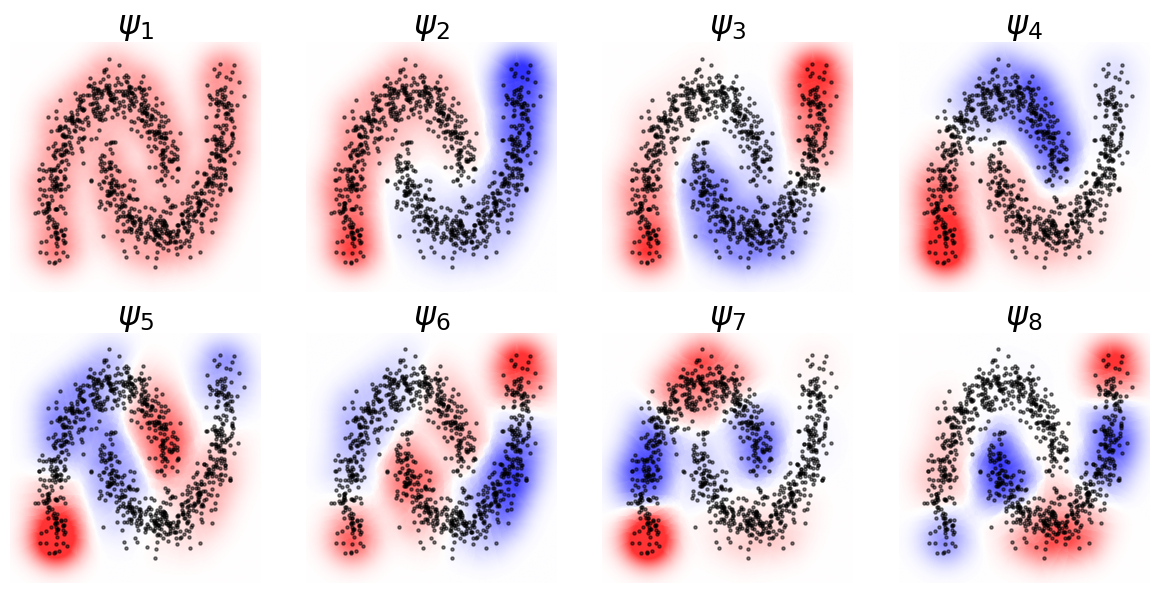

In [10]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

vmax = 3
for i, ax in enumerate(axes.flat, 1):
    ax.set_aspect('equal')
    im = ax.imshow(grid_eigvec_2d[:, :, i-1].transpose(1, 0), 
                   cmap='bwr', vmin=-vmax, vmax=vmax,
                   extent=[0, 1, 0, 1], origin='lower', alpha=0.8)
    ax.scatter(points[:, 0], points[:, 1], c='k', marker='o', s=5, alpha=0.5)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title(rf'$\psi_{{{i}}}$', fontsize=24)

plt.tight_layout()
plt.show()

In [11]:
input1 = np.array(input1)
input2 = np.array(input2)

eigvec1 = ncut.transform(torch.tensor(input1).float().unsqueeze(0))
eigvec2 = ncut.transform(torch.tensor(input2).float().unsqueeze(0))

In [ ]:
def find_cost(grid_eigvec, interpolated_eigvecs, ks):
    cost = 0
    for k in ks:
        left_eigvec = grid_eigvec[None, :, k]
        right_eigvec = interpolated_eigvecs[:, None, k]
        cost += ((left_eigvec - right_eigvec)**2)
    return cost

/tmp/ipykernel_89305/3356178846.py:25: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(path[:, 0], path[:, 1], c=colors[i], marker='s', s=100, alpha=1.0, edgecolors='none')


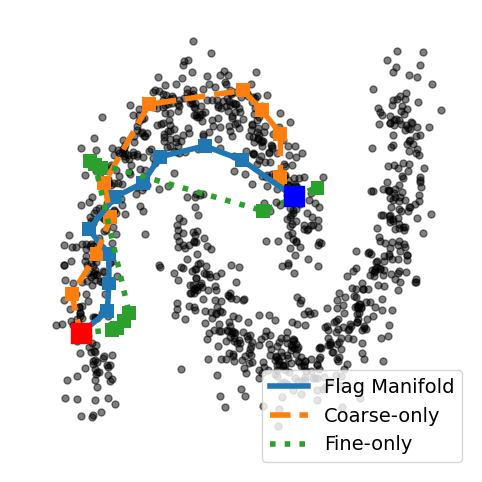

In [13]:
interpolation_weights = np.linspace(0.0, 1.0, 11)
interpolated_eigvecs = eigvec1 * (1 - interpolation_weights[:, None]) + eigvec2 * interpolation_weights[:, None]

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(points[:, 0], points[:, 1], c='k', marker='o', s=25, alpha=0.5)

line_styles = ['-', '--', ':', '-.']
labels = ['Flag Manifold', 'Coarse-only', 'Fine-only']
colors = [plt.get_cmap('tab10')(i) for i in range(3)]

# for i, ks in enumerate([[2, 4], [2], [4]]):
for i, ks in enumerate([[0, 1, 0, 1, 2, 3], [0, 1], [0, 1, 2, 3, 6]]):
    cost = find_cost(grid_eigvec, interpolated_eigvecs, ks)
    idxs = cost.argmin(1)
    path = flat_grid_xy[idxs]
    # prepend input1 to the path
    path = np.concatenate([input1[None, :], path], axis=0)
    # append input2 to the path
    path = np.concatenate([path, input2[None, :]], axis=0)
    ax.plot(path[:, 0], path[:, 1],
            linestyle=line_styles[i], 
            linewidth=4, 
            color=colors[i],
            label=labels[i])
    ax.scatter(path[:, 0], path[:, 1], c=colors[i], marker='s', s=100, alpha=1.0, edgecolors='none')

ax.scatter(input1[0], input1[1], c='red', marker='s', s=200, zorder=3)
ax.scatter(input2[0], input2[1], c='blue', marker='s', s=200, zorder=3)
ax.legend(loc='lower right', fontsize=14)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect('equal')
# ax.set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1], [''] * 6)
# ax.set_yticks([0, 0.2, 0.4, 0.6, 0.8, 1], [''] * 6)
ax.set_xticks([])
ax.set_yticks([])
# ax.grid(True)


ax.axis('off')
plt.show()

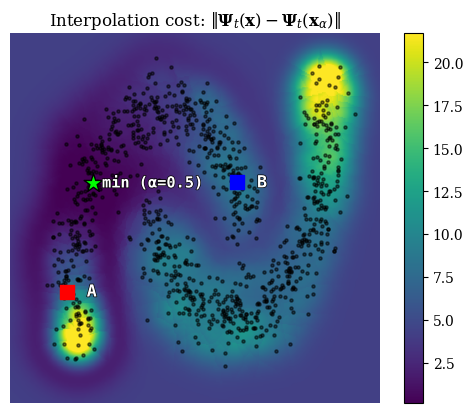

In [14]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

cost = find_cost(grid_eigvec, interpolated_eigvecs, [0, 1, 2, 3])
t_idx = 5
# Reshape cost for imshow
cost_2d = cost[t_idx].reshape(grid_size, grid_size).transpose(1, 0)
vmin = torch.quantile(cost_2d, 0.01)
vmax = torch.quantile(cost_2d, 0.99)
im = plt.imshow(cost_2d, cmap='viridis', extent=[0, 1, 0, 1], origin='lower', vmin=vmin, vmax=vmax)
plt.scatter(points[:, 0], points[:, 1], c='k', marker='o', s=5, alpha=0.5)
min_idx = cost[t_idx].argmin()
min_point = flat_grid_xy[min_idx]

# Get eigenvector values for the minimal point
min_eigvec = grid_eigvec[min_idx]

# Plot and annotate input A
plt.scatter(input1[0], input1[1], c='red', marker='s', s=100, zorder=3)
txt_a = plt.text(input1[0], input1[1], '  A', 
                 fontsize=12, color='white', weight='bold', va='center', family='monospace')
txt_a.set_path_effects([PathEffects.withStroke(linewidth=1, foreground='black')])

# Plot and annotate input B
plt.scatter(input2[0], input2[1], c='blue', marker='s', s=100, zorder=3)
txt_b = plt.text(input2[0], input2[1], '  B', 
                 fontsize=12, color='white', weight='bold', va='center', family='monospace')
txt_b.set_path_effects([PathEffects.withStroke(linewidth=1, foreground='black')])

# Plot and annotate minimal point
t = interpolation_weights[t_idx]
plt.scatter(min_point[0], min_point[1], c='lime', marker='*', s=200, zorder=3, edgecolors='black', linewidths=1)
txt_min = plt.text(min_point[0], min_point[1], f' min (α={t:.1f})', 
                   fontsize=11, color='white', weight='bold', va='center', family='monospace')
txt_min.set_path_effects([PathEffects.withStroke(linewidth=1, foreground='black')])

plt.title(r"Interpolation cost: $\left\| \mathbf{\Psi}_t(\mathbf{x}) - \mathbf{\Psi}_t(\mathbf{x}_\alpha) \right\|$")
plt.axis('off')
plt.colorbar(im)
plt.show()